In [ ]:
from collections import defaultdict
import glob
import json

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
from matplotlib.path import Path
import asf_search as asf
import pandas as pd
from cartopy.crs import NorthPolarStereo
from cartopy.feature import LAND

In [ ]:
ifile = '/Users/antonk/Data/dmi_asip/SEAICE_ARC_PHY_AUTO_L3_MYNRT_011_023/cmems_obs-si_arc_phy_nrt_l3_P1D_202411/2025/04/dmi_asip_seaice_mosaic_arc_l3_20250401.nc'
with xr.open_dataset(ifile) as ds:
    acq_time = ds['acq_time'][0, ::10, ::10].values
    sic = ds['sic'][0, ::10, ::10].values
    status_flag = ds['status_flag'][0, ::10, ::10].values
    xc = ds['xc'][::10].values
    yc = ds['yc'][::10].values

In [84]:
df = pd.read_feather('s1_stats_from_cmems.feather')

In [85]:
df['m'] = [datetime.fromtimestamp(t).month for t in df.t]

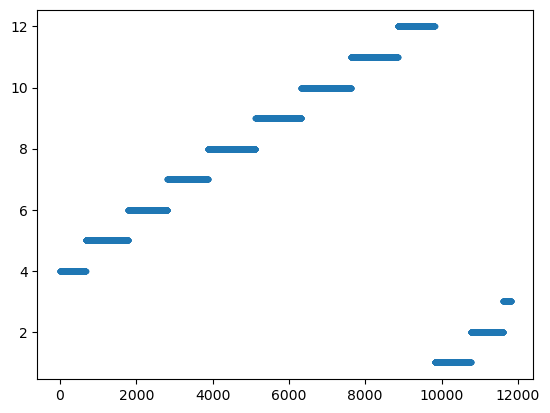

In [86]:
plt.plot(df.m, '.')

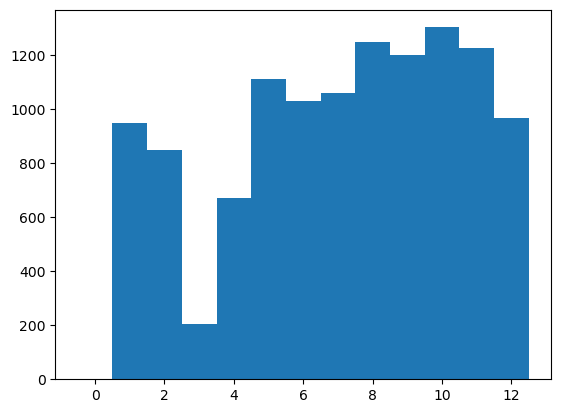

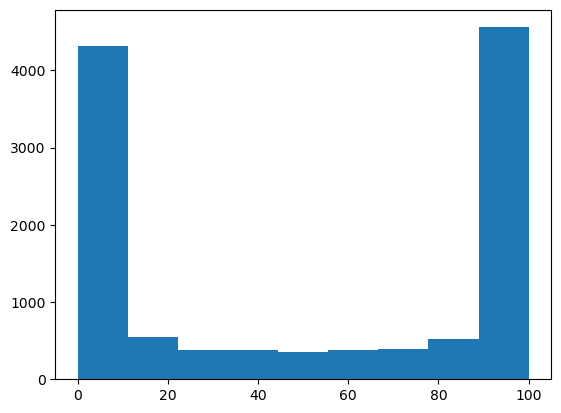

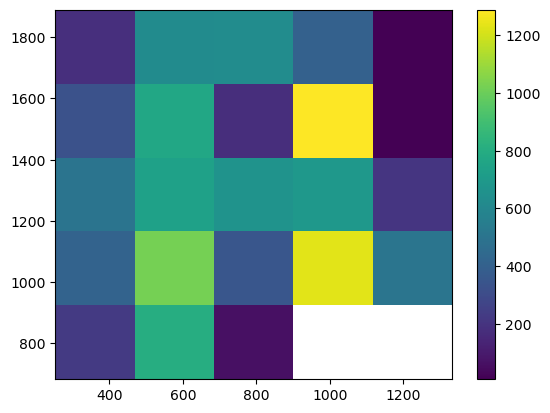

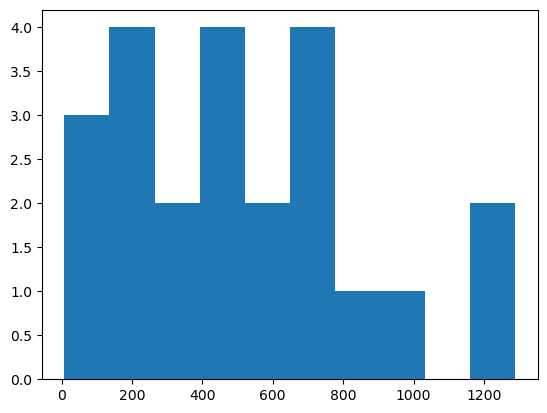

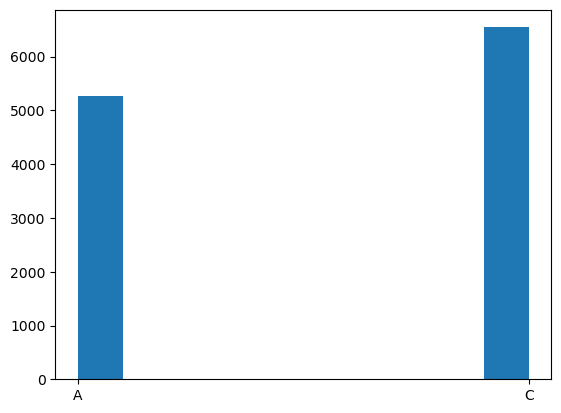

In [139]:
bins2d = 5
plt.hist(df.m, bins=np.arange(-0.5,13.5,1))
plt.show()

plt.hist(df.sic, bins=np.linspace(0,100,10))
plt.show()

pos_counts, _, _, _ = plt.hist2d(df.col, df.row, bins=bins2d, cmin=1)
plt.colorbar()
plt.show()

plt.hist(pos_counts[pos_counts > 0])
plt.show()

plt.hist(df.name.str[2].values)
plt.show()

In [160]:
pos_counts, col_bins, row_bins, _ = plt.hist2d(df.col, df.row, bins=bins2d, cmin=1)
plt.close()

med_count = np.percentile(pos_counts[pos_counts > 0], 50)
print(f'Median count per bin: {med_count}')
sampled_indices = []
for r in range(pos_counts.shape[0]):
    for c in range(pos_counts.shape[1]):
        if pos_counts[r, c] > 0:
            mask = (df.col >= col_bins[c]) & (df.col < col_bins[c+1]) & (df.row >= row_bins[r]) & (df.row < row_bins[r+1])
            bin_indices = df[mask].index.tolist()
            n_samples = min(len(bin_indices), int(med_count))
            sampled_indices.extend(np.random.choice(bin_indices, n_samples, replace=False))
df2 = df.loc[sampled_indices]

pos_counts2, col_bins, row_bins, _ = plt.hist2d(df2.col, df2.row, bins=(col_bins, row_bins), cmin=1)
plt.close()

med_count = np.percentile(pos_counts[pos_counts > 0], 50)
print(f'Median count per bin: {med_count}')

Median count per bin: 499.0
Median count per bin: 499.0


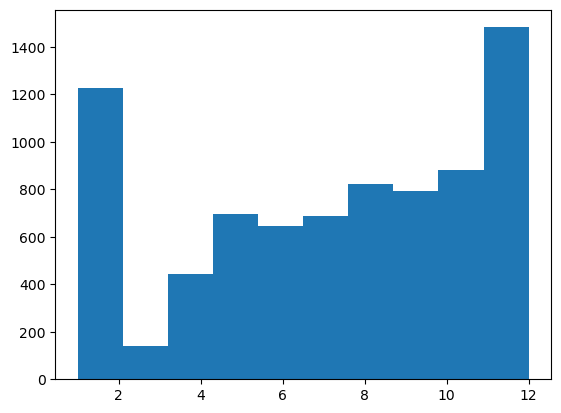

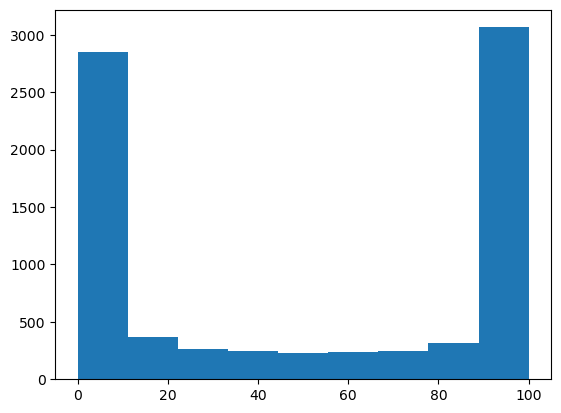

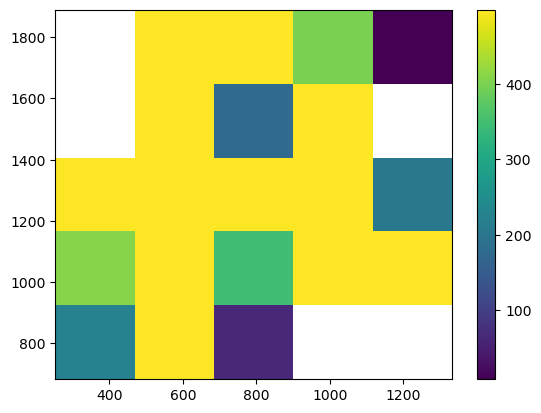

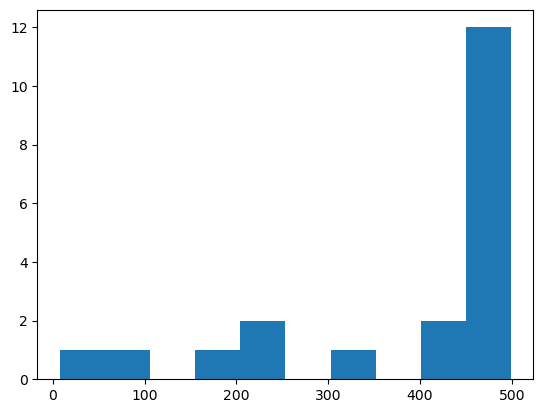

In [161]:
plt.hist(df2.m, bins=10)
plt.show()

plt.hist(df2.sic, bins=np.linspace(0,100,10))
plt.show()

pos_counts, _, _, _ = plt.hist2d(df2.col, df2.row, bins=(col_bins, row_bins), cmin=1)
plt.colorbar()
plt.show()

plt.hist(pos_counts[pos_counts > 0])
plt.show()


In [162]:
sic_counts, sic_bins = np.histogram(df2.sic.dropna(), bins=np.linspace(0, 100, 10))
med_count = np.median(sic_counts)
sampled_indices = []
for i in range(len(sic_counts)):
    mask = (df2.sic >= sic_bins[i]) & (df2.sic < sic_bins[i+1])
    bin_indices = df2[mask].index.tolist()
    n_samples = min(len(bin_indices), int(med_count))
    sampled_indices.extend(np.random.choice(bin_indices, n_samples, replace=False))

df3 = df2.loc[sampled_indices]
df3.shape

(2275, 7)

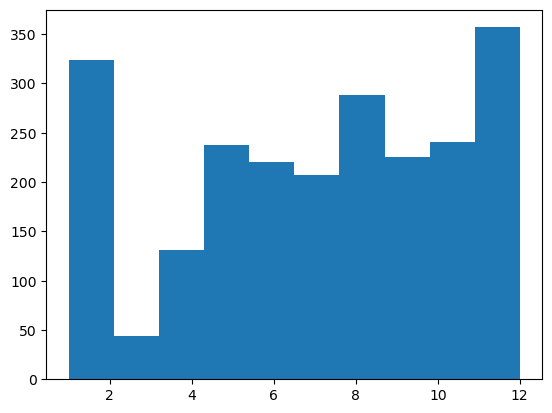

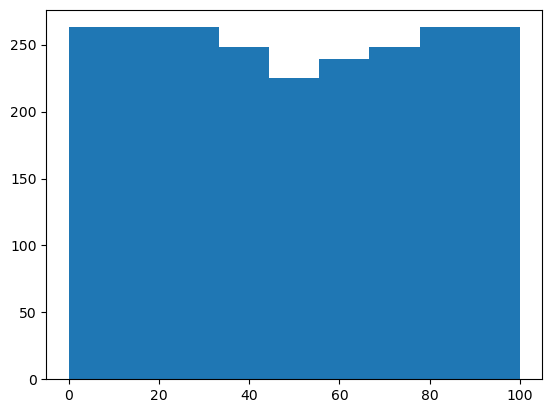

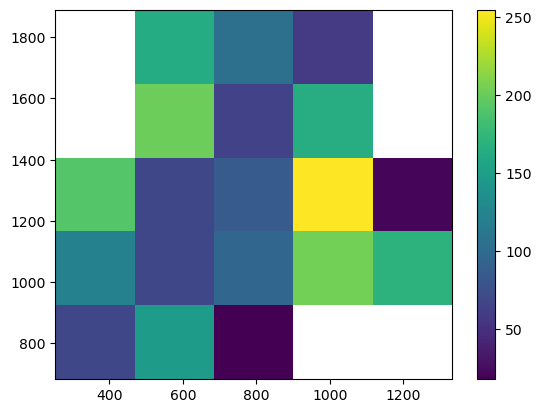

In [163]:
plt.hist(df3.m, bins=10)
plt.show()

plt.hist(df3.sic, bins=np.linspace(0,100,10))
plt.show()

plt.hist2d(df3.col, df3.row, bins=(col_bins, row_bins), cmin=1)
plt.colorbar()
plt.show()

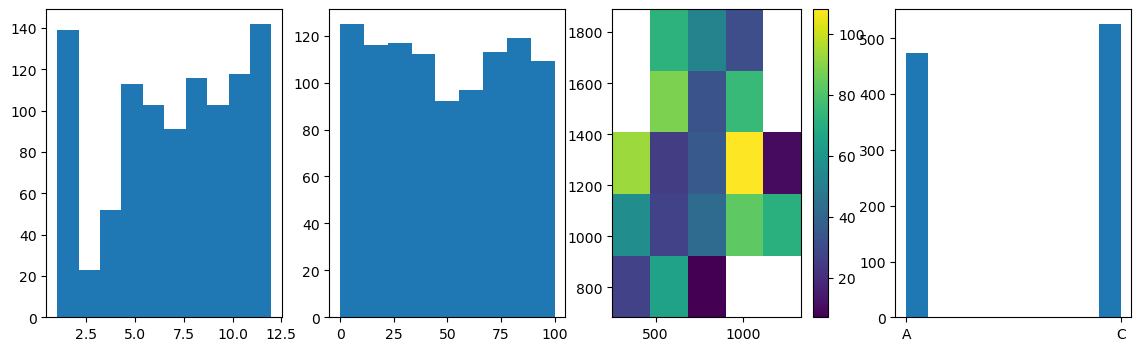

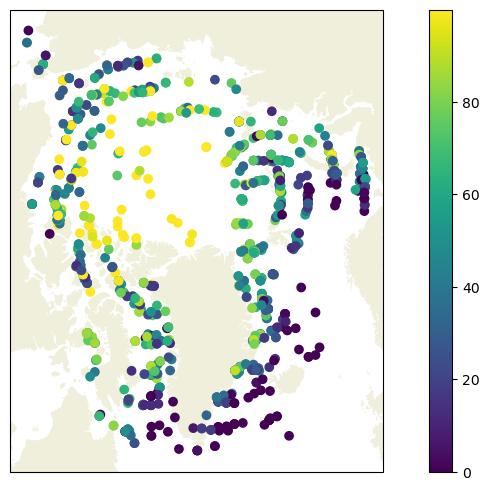

In [174]:
df4 = df3.sample(n=1000)

fig, axs = plt.subplots(1, 4, figsize=(14, 4))
axs[0].hist(df4.m, bins=10)
axs[1].hist(df4.sic, bins=np.linspace(0,100,10))
_, _, _, hist = axs[2].hist2d(df4.col, df4.row, bins=(col_bins, row_bins), cmin=1)
plt.colorbar(hist, ax=axs[2])
axs[3].hist(df4.name.str[2].values)
plt.show()

x = df4.col / (xc.size - 1) * (xc.max() - xc.min()) + xc.min()
y = yc.max() - df4.row / (yc.size - 1) * (yc.max() - yc.min())

fig, ax = plt.subplots(1, 1, figsize=(12, 6), subplot_kw={'projection': NorthPolarStereo(central_longitude=-45)})
scat = ax.scatter(x, y, c=df4.sic)
ax.add_feature(LAND)
plt.colorbar(scat)
plt.show()

In [182]:
df4.name.sort_values().to_csv('s1_names.csv', index=False)